In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input/complaint'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/complaint/complaints.csv


# Setup and imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from pathlib import Path

%matplotlib inline

# Load the dataset

In [3]:
df = pd.read_csv('/kaggle/input/complaint/complaints.csv')

/tmp/ipykernel_36/3782925459.py:1: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/kaggle/input/complaint/complaints.csv')


In [4]:
df.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,Experian Information Solutions Inc.,FL,32092,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195687
1,2025-06-20,Debt collection,Telecommunications debt,Attempts to collect debt not owed,Debt is not yours,NaN,Company can't verify or dispute the facts in t...,"Eastern Account Systems of Connecticut, Inc.",FL,342XX,NaN,NaN,Web,2025-06-20,Closed with explanation,Yes,NaN,14195688
2,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195689
3,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,Experian Information Solutions Inc.,AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195690
4,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account status incorrect,NaN,NaN,Experian Information Solutions Inc.,IL,60628,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195692


In [5]:
df.columns

Index(['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue',
       'Consumer complaint narrative', 'Company public response', 'Company',
       'State', 'ZIP code', 'Tags', 'Consumer consent provided?',
       'Submitted via', 'Date sent to company', 'Company response to consumer',
       'Timely response?', 'Consumer disputed?', 'Complaint ID'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9609797 entries, 0 to 9609796
Data columns (total 18 columns):
 #   Column                        Dtype 
---  ------                        ----- 
 0   Date received                 object
 1   Product                       object
 2   Sub-product                   object
 3   Issue                         object
 4   Sub-issue                     object
 5   Consumer complaint narrative  object
 6   Company public response       object
 7   Company                       object
 8   State                         object
 9   ZIP code                      object
 10  Tags                          object
 11  Consumer consent provided?    object
 12  Submitted via                 object
 13  Date sent to company          object
 14  Company response to consumer  object
 15  Timely response?              object
 16  Consumer disputed?            object
 17  Complaint ID                  int64 
dtypes: int64(1), object(17)
memory usage: 1.3+

In [7]:
df.shape

(9609797, 18)

# Overview of the datasest

In [8]:
eda_df = df.drop(columns=['Date received', 'Date sent to company'])

In [9]:
print(f"Shape: {df.shape}")
df.info()
eda_df.describe(include='object')

Shape: (9609797, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9609797 entries, 0 to 9609796
Data columns (total 18 columns):
 #   Column                        Dtype 
---  ------                        ----- 
 0   Date received                 object
 1   Product                       object
 2   Sub-product                   object
 3   Issue                         object
 4   Sub-issue                     object
 5   Consumer complaint narrative  object
 6   Company public response       object
 7   Company                       object
 8   State                         object
 9   ZIP code                      object
 10  Tags                          object
 11  Consumer consent provided?    object
 12  Submitted via                 object
 13  Date sent to company          object
 14  Company response to consumer  object
 15  Timely response?              object
 16  Consumer disputed?            object
 17  Complaint ID                  int64 
dtypes: int64(1), object(1

,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Company response to consumer,Timely response?,Consumer disputed?
count,9609797,9374502,9609791,8770275,2980756,4839590,9609797,9555281,9579569,628768,7960236,9609797,9609777,9609797,768299
unique,21,86,178,272,2108758,11,7674,63,34965,3,4,7,8,2,2
top,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,In accordance with the Fair Credit Reporting a...,Company has responded to the consumer and the ...,"EQUIFAX, INC.",FL,XXXXX,Servicemember,Consent not provided,Web,Closed with explanation,Yes,No
freq,4834855,6955847,3613761,2324057,21622,4537468,2321626,1273171,172807,391563,4639279,9017914,5487712,9535859,619921


### Convert to date data type

In [10]:
df['Date received'] = pd.to_datetime(df['Date received'], errors='coerce')

In [11]:
df['Date sent to company'] = pd.to_datetime(df['Date sent to company'], errors='coerce')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9609797 entries, 0 to 9609796
Data columns (total 18 columns):
 #   Column                        Dtype         
---  ------                        -----         
 0   Date received                 datetime64[ns]
 1   Product                       object        
 2   Sub-product                   object        
 3   Issue                         object        
 4   Sub-issue                     object        
 5   Consumer complaint narrative  object        
 6   Company public response       object        
 7   Company                       object        
 8   State                         object        
 9   ZIP code                      object        
 10  Tags                          object        
 11  Consumer consent provided?    object        
 12  Submitted via                 object        
 13  Date sent to company          datetime64[ns]
 14  Company response to consumer  object        
 15  Timely response?              ob

# Check for Missing Values

In [13]:
missing = df.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0])

Tags                            8981029
Consumer disputed?              8841498
Consumer complaint narrative    6629041
Company public response         4770207
Consumer consent provided?      1649561
Sub-issue                        839522
Sub-product                      235295
State                             54516
ZIP code                          30228
Company response to consumer         20
Issue                                 6
dtype: int64


In [14]:
df.shape

(9609797, 18)

#### Impute high-missing categorical columns with custom string values


In [15]:
df['Tags'] = df['Tags'].fillna('No Tag')
df['Consumer disputed?'] = df['Consumer disputed?'].fillna('Unknown')
df['Consumer complaint narrative'] = df['Consumer complaint narrative'].fillna('No narrative provided')
df['Company public response'] = df['Company public response'].fillna('No public response')
df['Consumer consent provided?'] = df['Consumer consent provided?'].fillna('Not provided')

In [16]:
# Impute with mode for selected columns
mode_cols = ['Sub-issue', 'Sub-product', 'State', 'ZIP code', 'Company response to consumer', 'Issue']

for col in mode_cols:
    mode_value = df[col].mode()[0]  # Get the most frequent value
    df[col].fillna(mode_value, inplace=True)

/tmp/ipykernel_36/2171612985.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mode_value, inplace=True)


In [17]:
missing = df.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0])

Series([], dtype: int64)


# Analysis

In [18]:
df['YearMonth'] = df['Date received'].dt.to_period('M').astype(str)

In [19]:
plt.style.use('seaborn')  # Use valid built-in style
figures = []

/tmp/ipykernel_36/349680804.py:1: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')  # Use valid built-in style


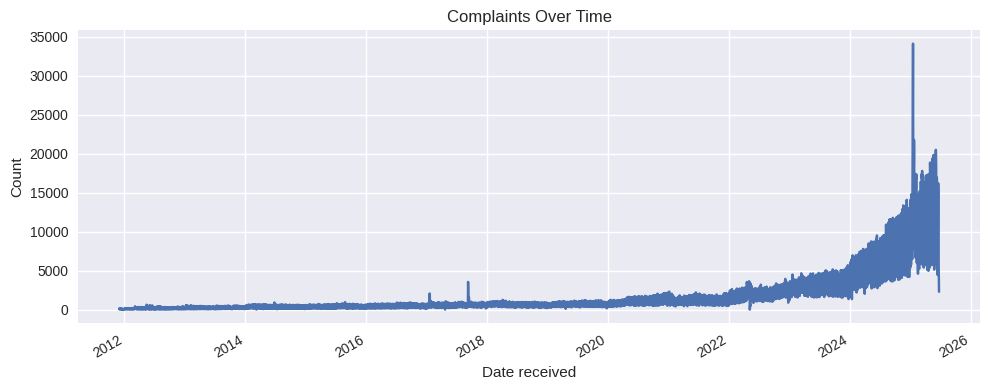

In [20]:
# Complaints Over Time
fig, ax = plt.subplots(figsize=(10, 4))
df.groupby('Date received').size().plot(ax=ax, title='Complaints Over Time', ylabel='Count')

plt.tight_layout()
plt.show()


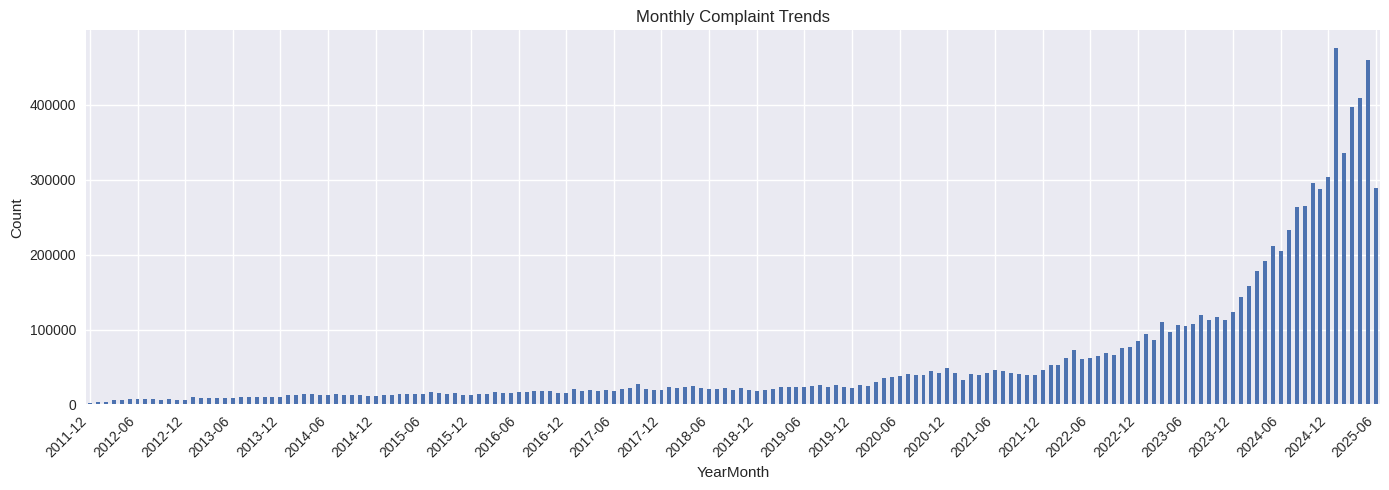

In [21]:
#  Monthly Complaint Trends
fig, ax = plt.subplots(figsize=(14, 5))

monthly_counts = df.groupby('YearMonth').size()
monthly_counts.plot(kind='bar', ax=ax, title='Monthly Complaint Trends', ylabel='Count')

# Reduce number of x-ticks
xticks = ax.get_xticks()
ax.set_xticks(xticks[::6])  # show every 6th label
ax.set_xticklabels(monthly_counts.index[::6], rotation=45, ha='right')

plt.tight_layout()
plt.show()



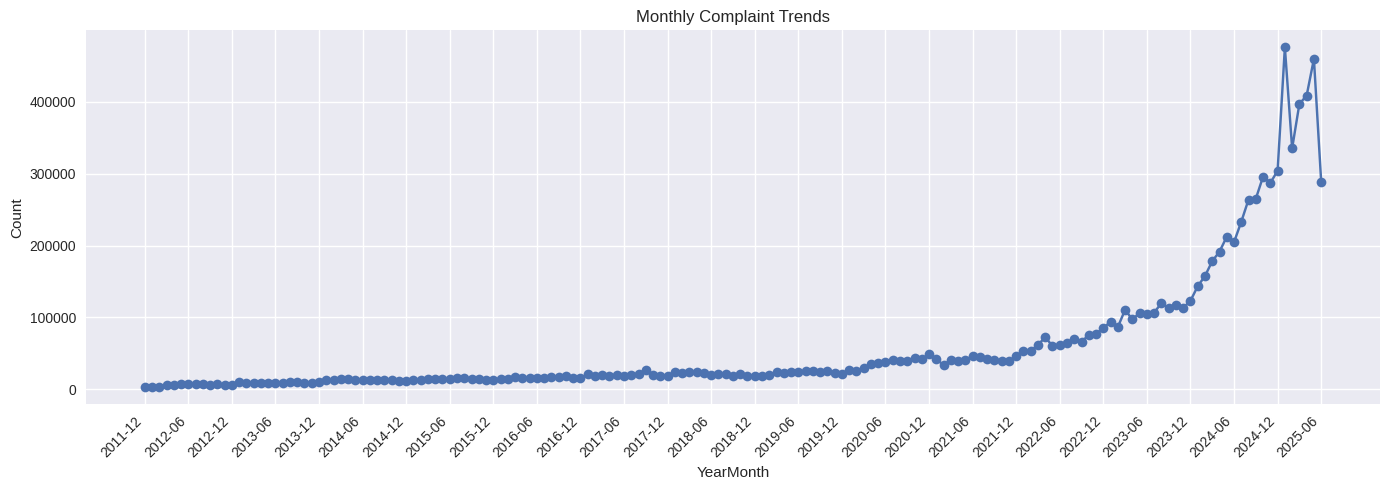

In [22]:
fig, ax = plt.subplots(figsize=(14, 5))
monthly_counts.plot(kind='line', marker='o', ax=ax, title='Monthly Complaint Trends', ylabel='Count')
ax.set_xticks(range(0, len(monthly_counts), 6))
ax.set_xticklabels(monthly_counts.index[::6], rotation=45, ha='right')

plt.tight_layout()
plt.show()


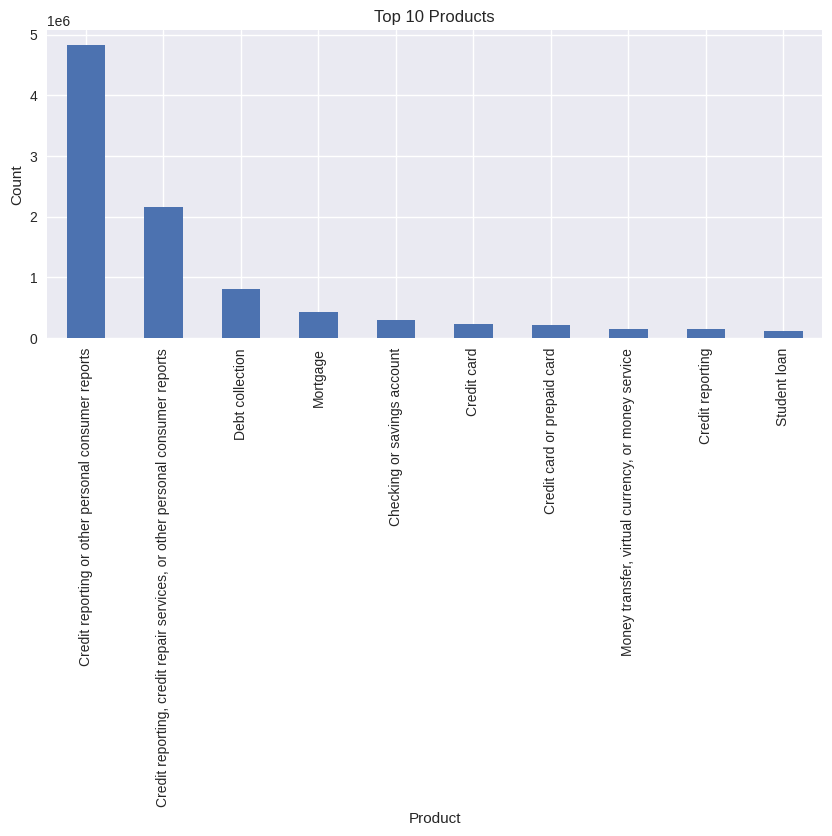

In [23]:
# Top 10 Products
fig, ax = plt.subplots(figsize=(10, 4))
df['Product'].value_counts().head(10).plot(kind='bar', ax=ax, title='Top 10 Products', ylabel='Count')
figures.append(fig)



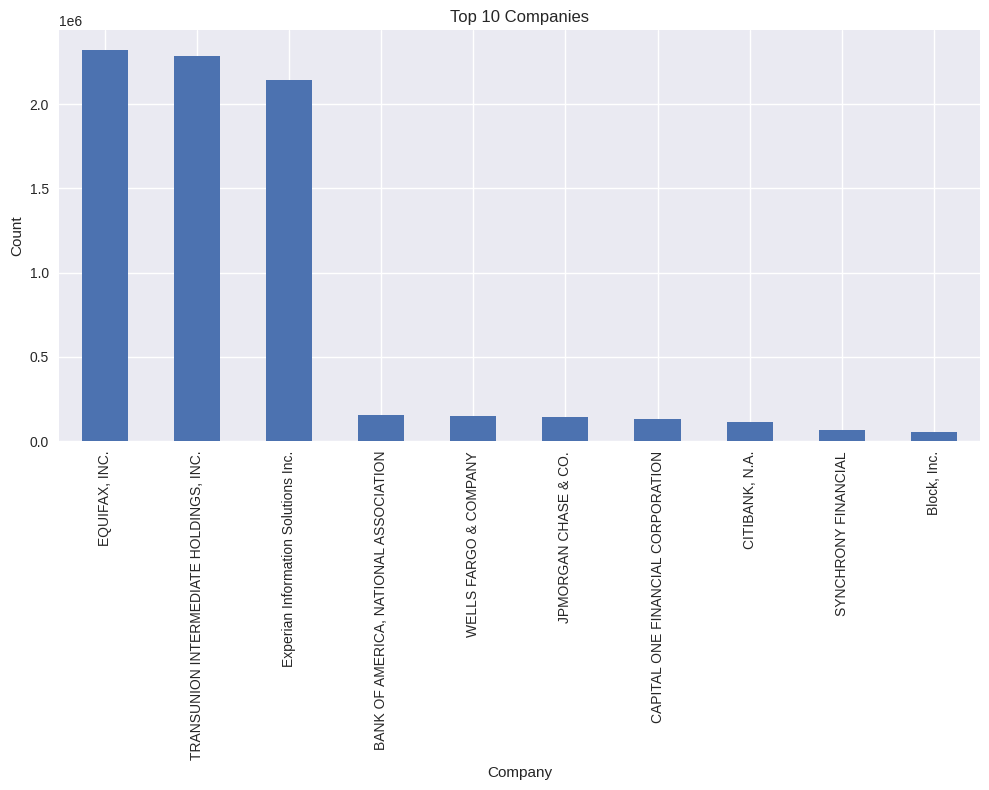

In [24]:
# Top 10 Companies
fig, ax = plt.subplots(figsize=(10, 8))
df['Company'].value_counts().head(10).plot(kind='bar', ax=ax, title='Top 10 Companies', ylabel='Count')

plt.tight_layout()
plt.show()

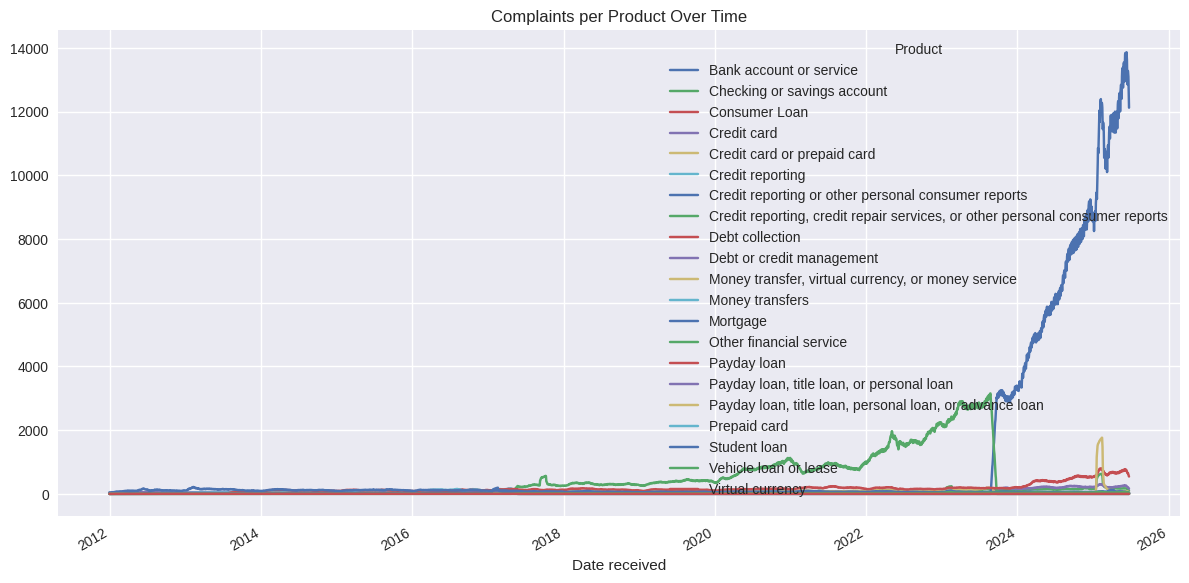

In [25]:
# Complaints per product over time

fig, ax = plt.subplots(figsize=(12, 6))
df.groupby(['Date received', 'Product']).size().unstack().fillna(0).rolling(30).mean().plot(ax=ax, title='Complaints per Product Over Time')
plt.tight_layout()
plt.show()

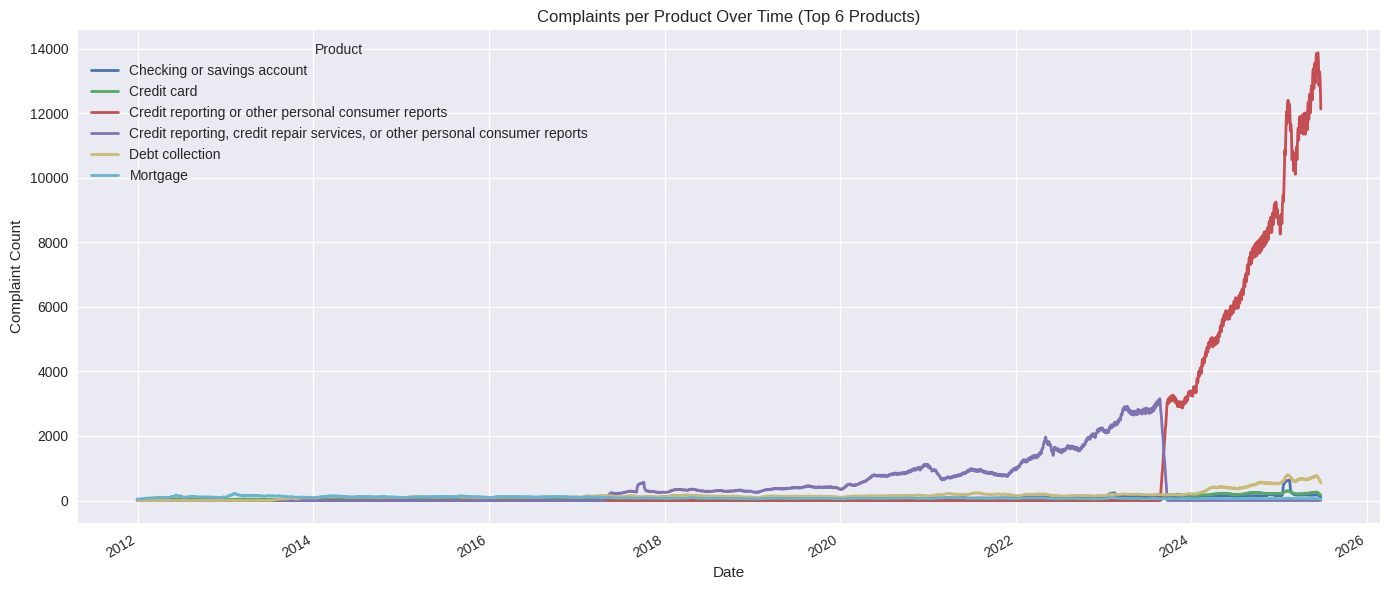

In [26]:
# Get top N products by frequency
top_products = df['Product'].value_counts().head(6).index

# Filter DataFrame to only those products
filtered_df = df[df['Product'].isin(top_products)]

# Group and smooth
product_time_series = (
    filtered_df.groupby(['Date received', 'Product'])
    .size()
    .unstack()
    .fillna(0)
    .rolling(30)
    .mean()
)

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
product_time_series.plot(ax=ax, title='Complaints per Product Over Time (Top 6 Products)', linewidth=2)

ax.set_ylabel('Complaint Count')
ax.set_xlabel('Date')
ax.legend(title='Product', loc='upper left')
fig.tight_layout()


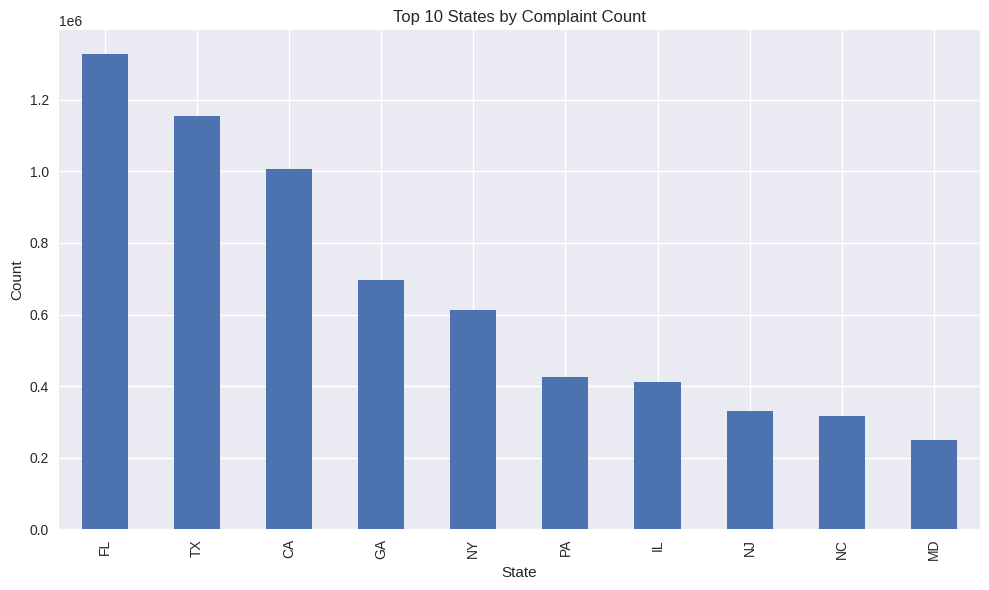

In [27]:
# State-wise Complaints
fig, ax = plt.subplots(figsize=(10, 6))
df['State'].value_counts().head(10).plot(kind='bar', ax=ax, title='Top 10 States by Complaint Count', ylabel='Count')

plt.tight_layout()
plt.show()

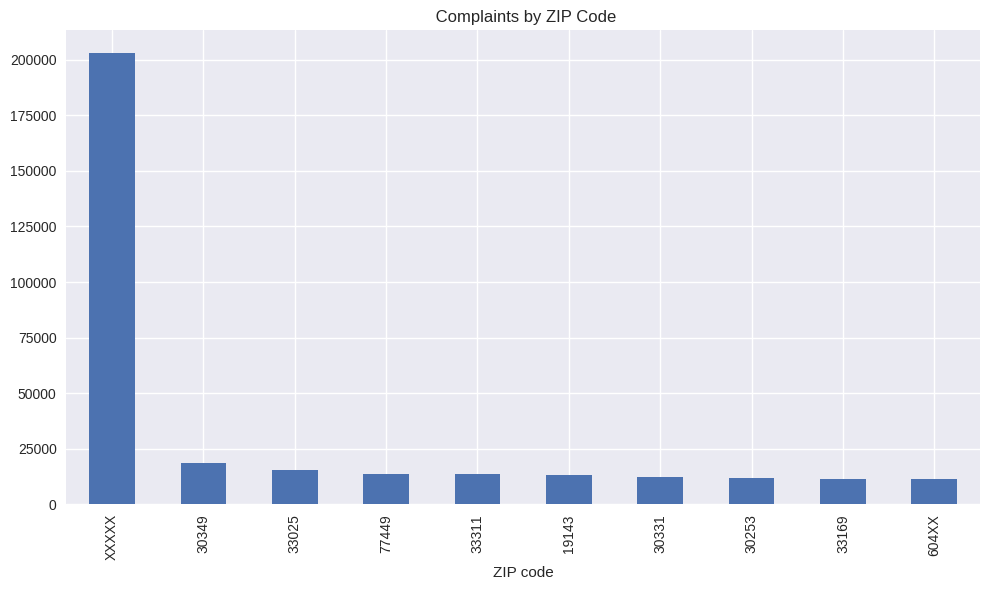

In [28]:
# Complaints by ZIP Code
fig, ax = plt.subplots(figsize=(10, 6))
df['ZIP code'].value_counts().head(10).plot(kind='bar', ax=ax, title=' Complaints by ZIP Code')
plt.tight_layout()
plt.show()

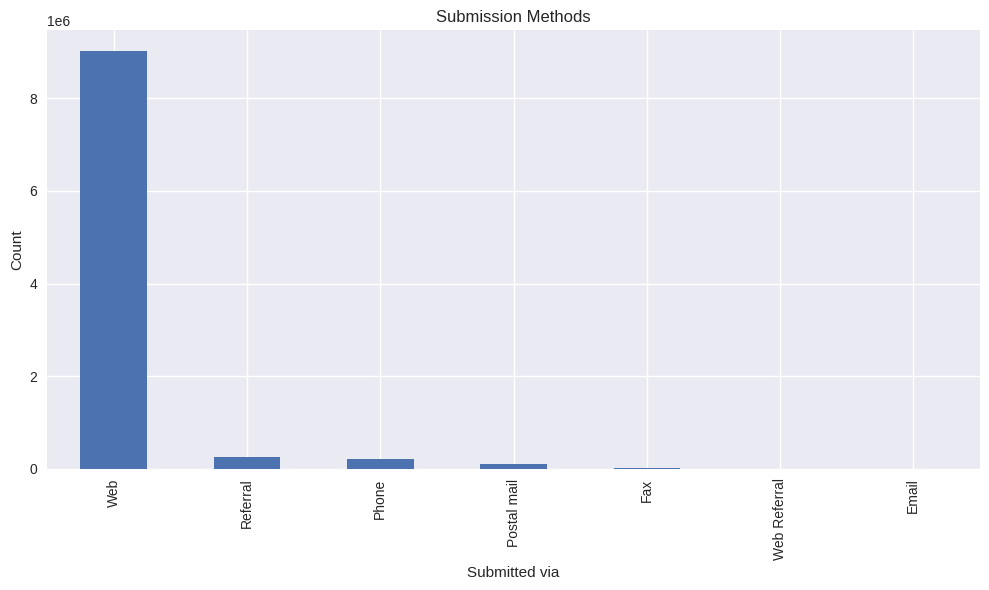

In [29]:
# Submitted via method
fig, ax = plt.subplots(figsize=(10, 6))
df['Submitted via'].value_counts().plot(kind='bar', ax=ax, title='Submission Methods', ylabel='Count')
plt.tight_layout()
plt.show()

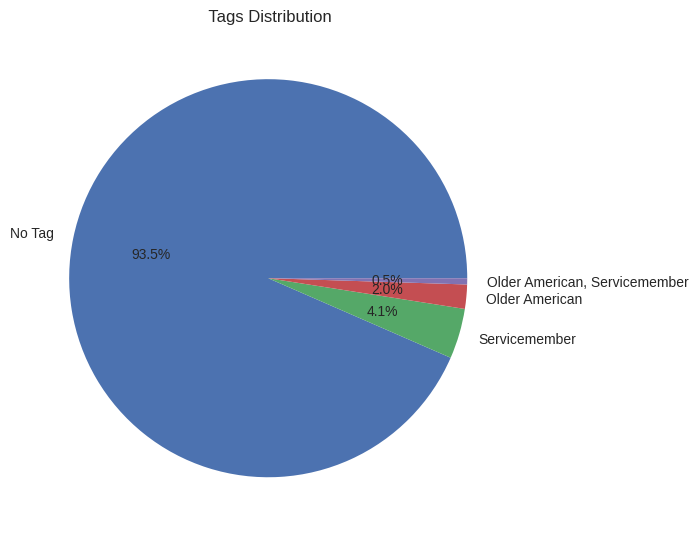

In [30]:
# Tags Distribution
fig, ax = plt.subplots(figsize=(7, 7))
df['Tags'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=ax, title=' Tags Distribution')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

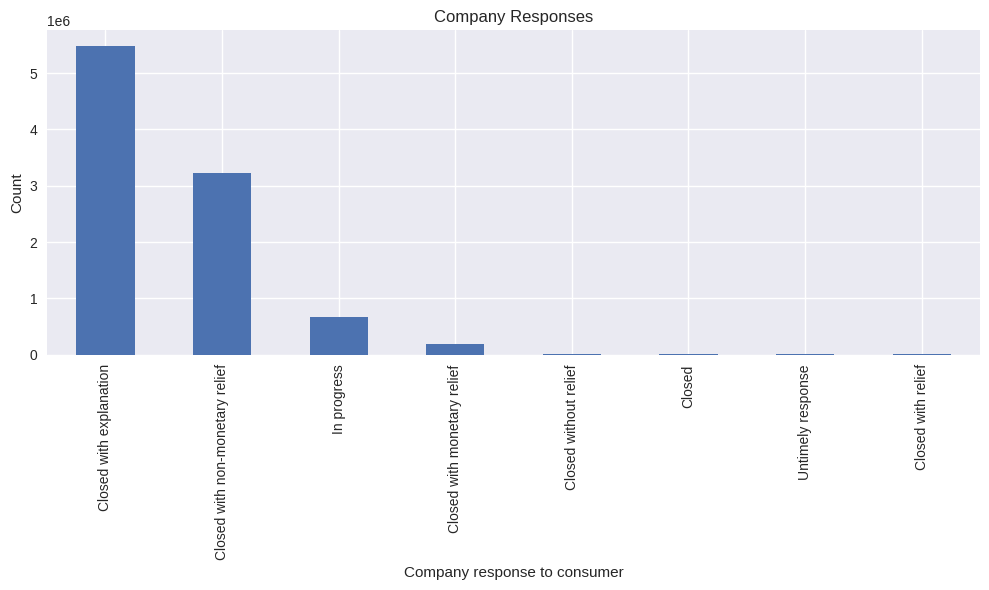

In [31]:
# Company Response to Consumer
fig, ax = plt.subplots(figsize=(10, 6))
df['Company response to consumer'].value_counts().plot(kind='bar', ax=ax, title='Company Responses', ylabel='Count')
plt.tight_layout()
plt.show()

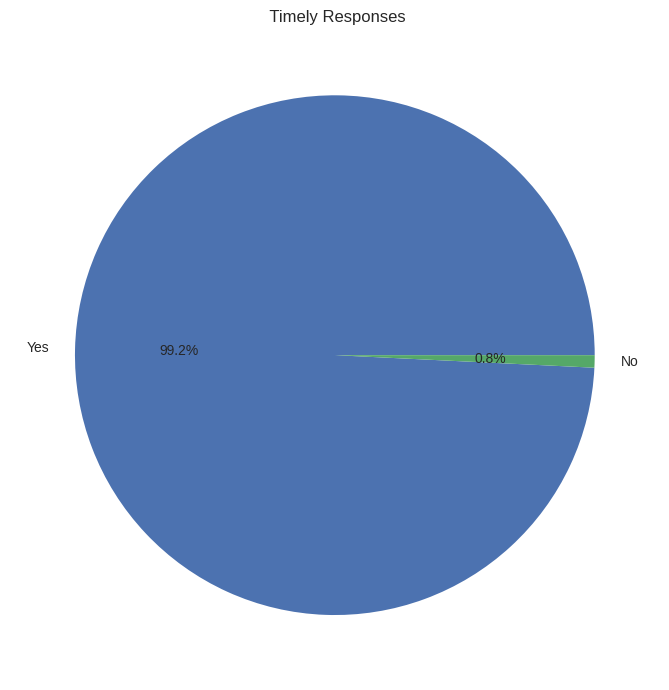

In [32]:
# Timely Response (Yes/No)
fig, ax = plt.subplots(figsize=(7, 7))
df['Timely response?'].value_counts().plot(kind='pie', ax=ax, autopct='%1.1f%%', title=' Timely Responses')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

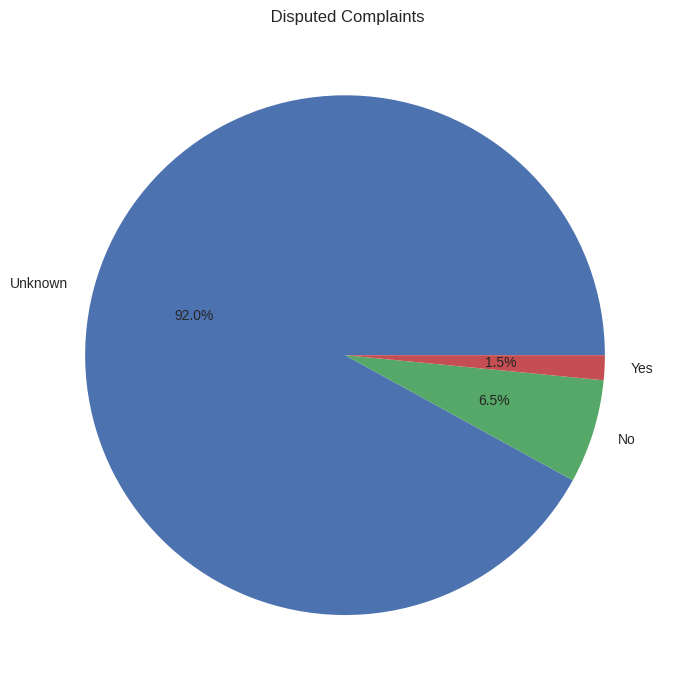

In [33]:
# Disputed Complaints
fig, ax = plt.subplots(figsize=(7, 7))
df['Consumer disputed?'].value_counts().plot(kind='pie', ax=ax, autopct='%1.1f%%', title=' Disputed Complaints')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

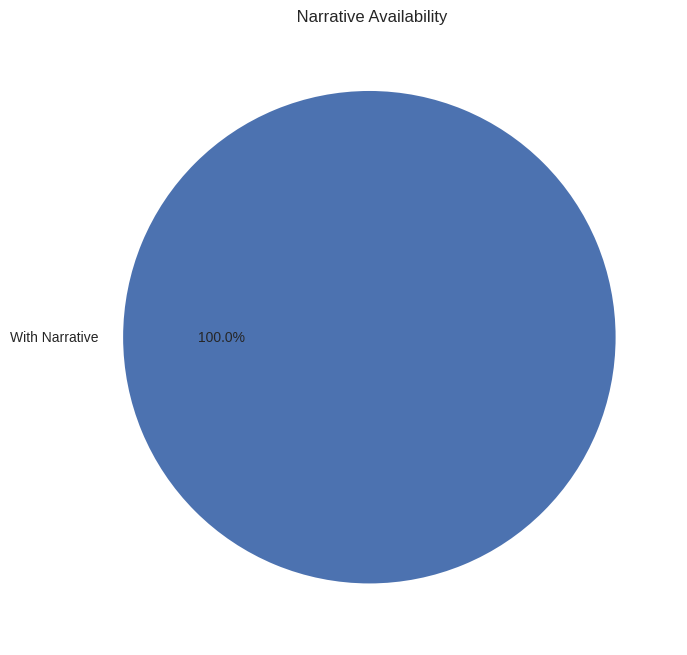

In [34]:
# Narrative Availability
fig, ax = plt.subplots(figsize=(7, 7))
narrative_presence = df['Consumer complaint narrative'].apply(lambda x: 'With Narrative' if isinstance(x, str) and x.strip() != '' else 'No Narrative')
narrative_presence.value_counts().plot(kind='pie', autopct='%1.1f%%', ax=ax, title=' Narrative Availability')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

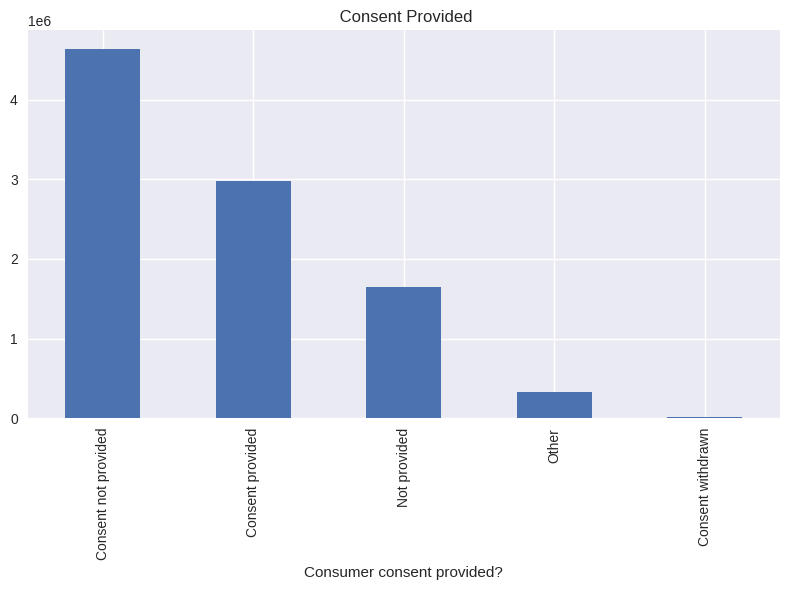

In [35]:
# Consent Provided
fig, ax = plt.subplots(figsize=(8, 6))
df['Consumer consent provided?'].value_counts().plot(kind='bar', ax=ax, title=' Consent Provided')
figures.append(fig)
plt.tight_layout()
plt.show()

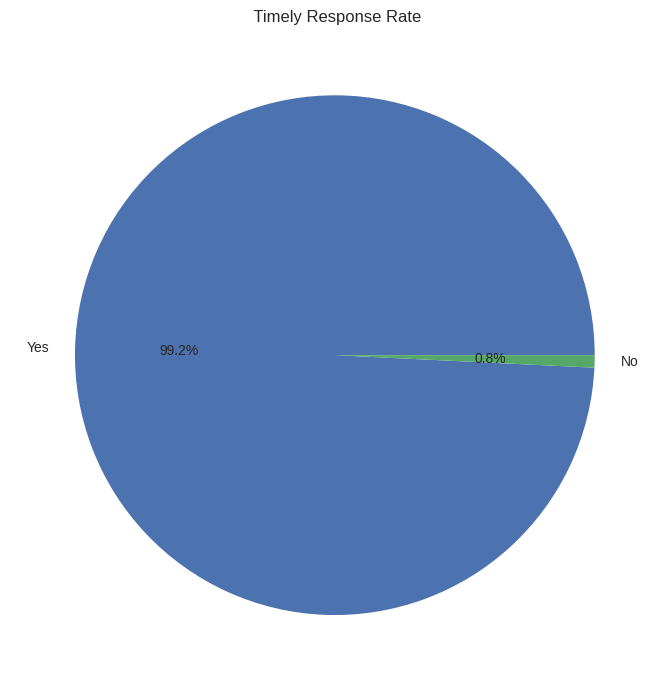

In [36]:
# Timely Response Rate
fig, ax = plt.subplots(figsize=(7, 7))
df['Timely response?'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=ax, title=' Timely Response Rate')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

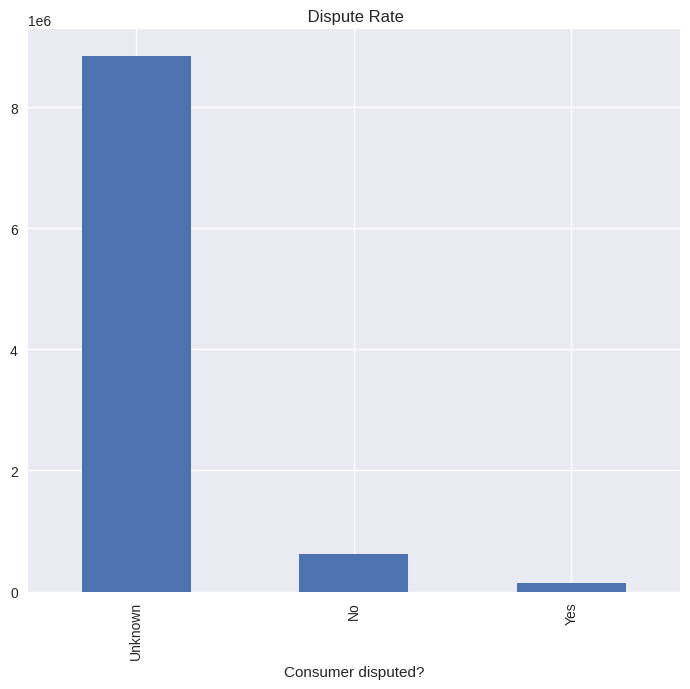

In [37]:
# Dispute Rate
fig, ax = plt.subplots(figsize=(7, 7))
df['Consumer disputed?'].value_counts().plot(kind='bar', ax=ax, title=' Dispute Rate')
plt.tight_layout()
plt.show()

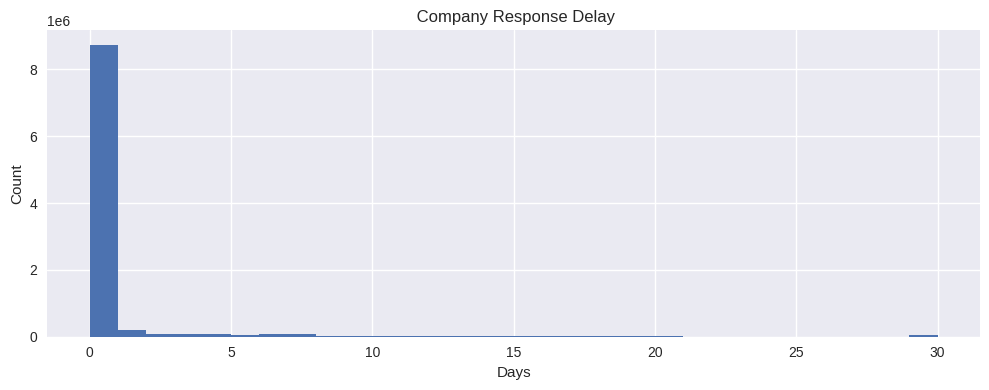

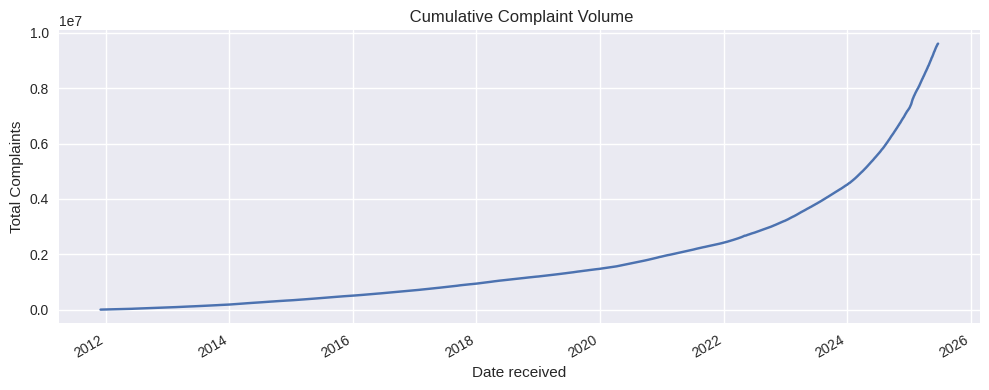

In [38]:
# Company Response Delay (if date sent exists)
if 'Date sent to company' in df.columns:
    df['Date sent to company'] = pd.to_datetime(df['Date sent to company'], errors='coerce')
    df['Response Delay (Days)'] = (df['Date sent to company'] - df['Date received']).dt.days
    fig, ax = plt.subplots(figsize=(10, 4))
    df['Response Delay (Days)'].dropna().clip(0, 30).hist(bins=30, ax=ax)
    ax.set_title(' Company Response Delay')
    ax.set_xlabel('Days')
    ax.set_ylabel('Count')
    plt.tight_layout()
    plt.show()

# Complaint ID Trend (assuming unique index or ID over time)
fig, ax = plt.subplots(figsize=(10, 4))
df.groupby('Date received').size().cumsum().plot(ax=ax, title=' Cumulative Complaint Volume', ylabel='Total Complaints')

plt.tight_layout()
plt.show()

# Distribution of Complaints by Product

## How many types of Product ?

In [39]:
# Show unique product types
unique_products = df['Product'].unique()
print("Unique product types:")
for product in unique_products:
    print("-", product)

Unique product types:
- Credit reporting or other personal consumer reports
- Debt collection
- Credit card
- Checking or savings account
- Money transfer, virtual currency, or money service
- Vehicle loan or lease
- Debt or credit management
- Mortgage
- Payday loan, title loan, personal loan, or advance loan
- Prepaid card
- Student loan
- Credit reporting
- Credit reporting, credit repair services, or other personal consumer reports
- Credit card or prepaid card
- Payday loan, title loan, or personal loan
- Bank account or service
- Money transfers
- Consumer Loan
- Payday loan
- Other financial service
- Virtual currency


In [40]:
product_counts = df['Product'].value_counts()
print("\nNumber of complaints by product:")
print(product_counts)


Number of complaints by product:
Product
Credit reporting or other personal consumer reports                             4834855
Credit reporting, credit repair services, or other personal consumer reports    2163857
Debt collection                                                                  799197
Mortgage                                                                         422254
Checking or savings account                                                      291178
Credit card                                                                      226686
Credit card or prepaid card                                                      206369
Money transfer, virtual currency, or money service                               145066
Credit reporting                                                                 140429
Student loan                                                                     109717
Bank account or service                                                       

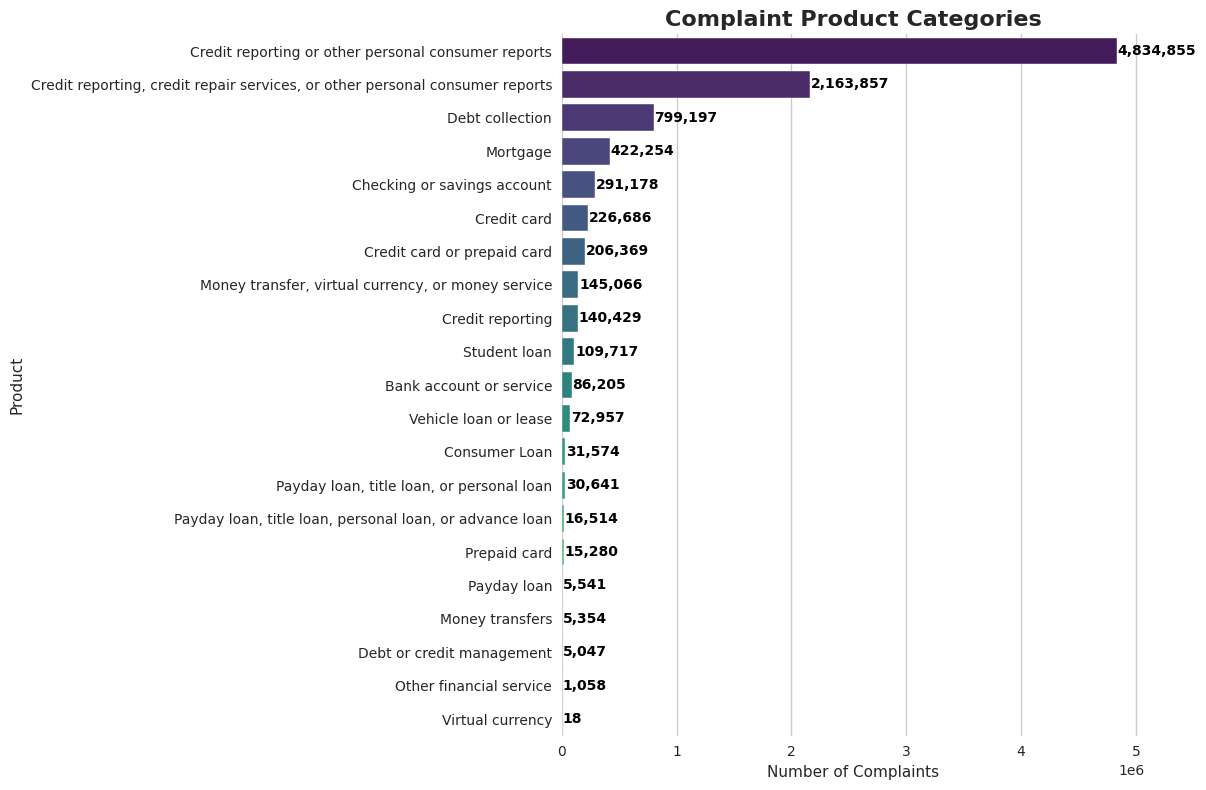

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare top 15 products
top_products = df['Product'].value_counts()

# Set the style
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Plot
palette = sns.color_palette("viridis", len(top_products))
bars = sns.barplot(x=top_products.values, y=top_products.index, palette=palette)

# Add value labels
for i, v in enumerate(top_products.values):
    bars.text(v + 5000, i, f'{v:,}', color='black', va='center', fontweight='bold')

# Title and labels
plt.title('Complaint Product Categories', fontsize=16, fontweight='bold')
plt.xlabel('Number of Complaints')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

# Analyze Complaint Narrative Length

## Add Word Count Column

In [42]:
df['Narrative Length'] = df['Consumer complaint narrative'].fillna('').apply(lambda x: len(x.split()))

In [43]:
print(df['Narrative Length'].describe())

count    9.609797e+06
mean     5.653613e+01
std      1.490192e+02
min      1.000000e+00
25%      3.000000e+00
50%      3.000000e+00
75%      5.000000e+01
max      6.469000e+03
Name: Narrative Length, dtype: float64


## Narrative Length

In [44]:
# non_empty_df = df[df['Narrative Length'] > 0]

average_length = df['Narrative Length'].mean()
print(f"📏 Average word count: {average_length:.2f} words")


📏 Average word count: 56.54 words


## Visualize Length Distribution

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


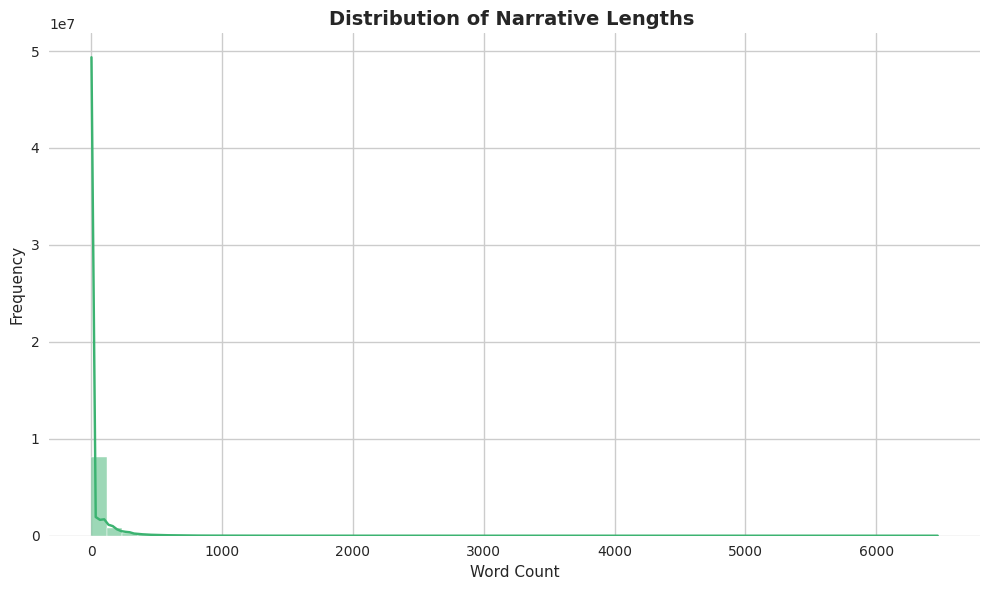

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['Narrative Length'], bins=55, kde=True, color='mediumseagreen')
plt.title('Distribution of Narrative Lengths ', fontsize=14, fontweight='bold')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()


## Boxplot

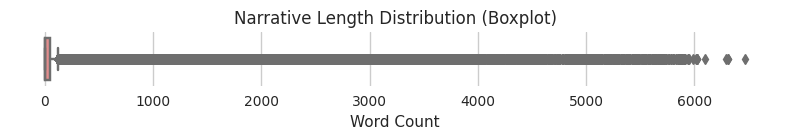

In [46]:
plt.figure(figsize=(8, 1.5))
sns.boxplot(x=df['Narrative Length'], color='lightcoral')
plt.title('Narrative Length Distribution (Boxplot)')
plt.xlabel('Word Count')
plt.tight_layout()
plt.show()


## Very Short or Long Narratives?

In [47]:
print("Short narratives (<20 words):", (df['Narrative Length'] < 20).sum())
print("Long narratives (>500 words):", (df['Narrative Length'] > 500).sum())

Short narratives (<20 words): 6753289
Long narratives (>500 words): 160989


In [48]:
short_count = (df['Narrative Length'] < 20).sum()
long_count = (df['Narrative Length'] > 500).sum()
medium_count = ((df['Narrative Length'] >= 20) & (df['Narrative Length'] <= 500)).sum()

In [49]:
def func(pct, all_vals):
    absolute = int(round(pct/100.*sum(all_vals)))
    return f"{pct:.1f}%\n({absolute:,})"

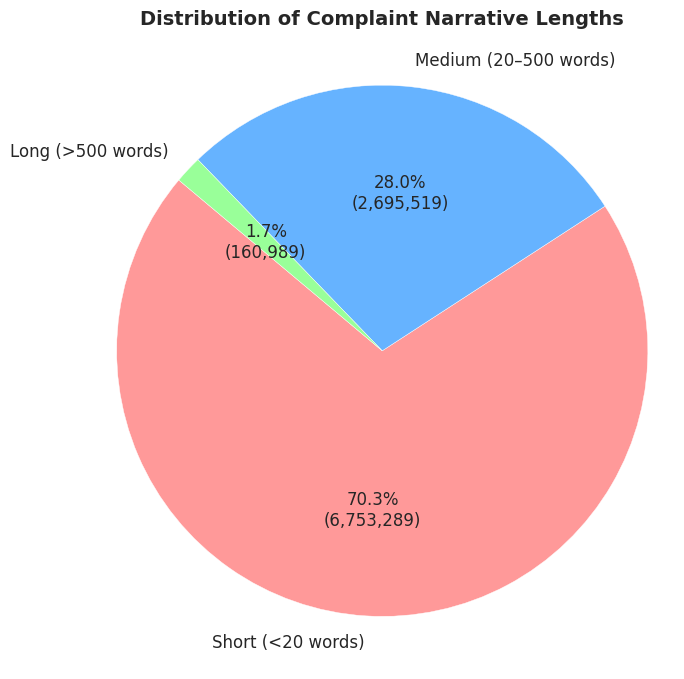

In [50]:
import matplotlib.pyplot as plt

# Labels and sizes
labels = ['Short (<20 words)', 'Medium (20–500 words)', 'Long (>500 words)']
sizes = [short_count, medium_count, long_count]
colors = ['#ff9999','#66b3ff','#99ff99']

# Plot
plt.figure(figsize=(7, 7))
plt.pie(sizes, labels=labels, colors=colors,
        autopct=lambda pct: func(pct, sizes),
        startangle=140, textprops={'fontsize': 12})
# plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140, textprops={'fontsize': 12})
plt.title('Distribution of Complaint Narrative Lengths', fontsize=14, fontweight='bold')
plt.axis('equal')  # Equal aspect ratio ensures pie is drawn as a circle.
plt.tight_layout()
plt.show()


## Complaints With vs. Without Narratives

Complaints with narratives: 9609797
Complaints without narratives: 0


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


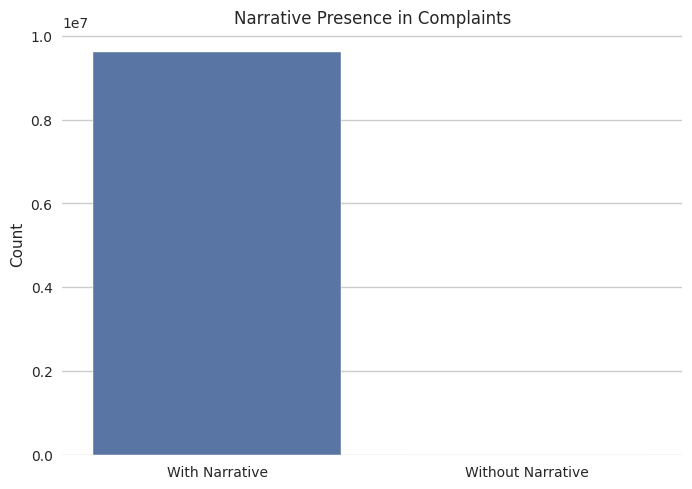

In [51]:
has_narrative = df['Consumer complaint narrative'].notnull().sum()
no_narrative = df['Consumer complaint narrative'].isnull().sum()

print(f"Complaints with narratives: {has_narrative}")
print(f"Complaints without narratives: {no_narrative}")

sns.barplot(x=['With Narrative', 'Without Narrative'], y=[has_narrative, no_narrative])
plt.title('Narrative Presence in Complaints')
plt.ylabel('Count')
plt.show()

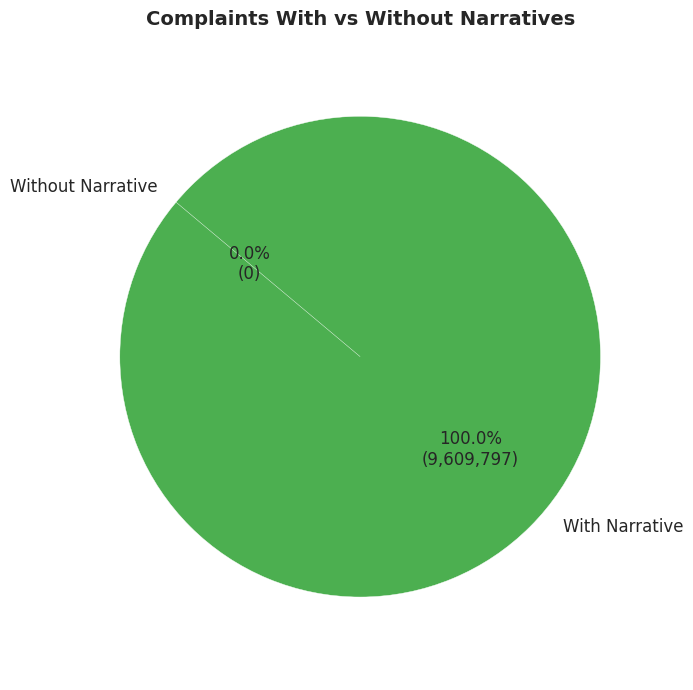

In [52]:
labels = ['With Narrative', 'Without Narrative']
sizes = [has_narrative, no_narrative]
colors = ['#4CAF50', '#F44336']

plt.figure(figsize=(7, 7))
plt.pie(sizes, labels=labels, colors=colors,
        autopct=lambda pct: func(pct, sizes),
        startangle=140, textprops={'fontsize': 12})
plt.title('Complaints With vs Without Narratives', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

## Filter Dataset to Specified Products

In [53]:
selected_products = [
    'Credit card', 'Personal loan', 'Buy Now, Pay Later (BNPL)', 
    'Savings account', 'Money transfers'
]

filtered_df = df[df['Product'].isin(selected_products)].copy()
filtered_df.reset_index(drop=True, inplace=True)

print(f"Filtered dataset shape: {filtered_df.shape}")


Filtered dataset shape: (232040, 21)


## Clean Narrative Text

In [54]:
import pandas as pd
import re

# Optional: Add stopword removal and lemmatization later if needed

def clean_text(text):
    if pd.isnull(text):
        return ""

    # Lowercase
    text = text.lower()

    # Remove boilerplate phrases (customizable)
    boilerplate_patterns = [
        r"i am writing to file a complaint", 
        r"i am writing to complain about", 
        r"i am reaching out", 
        r"this is regarding", 
        r"to whom it may concern"
    ]
    for pattern in boilerplate_patterns:
        text = re.sub(pattern, "", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)

    # Remove email addresses and phone numbers
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'\b\d{10,}\b', '', text)

    # Remove special characters, punctuation (preserve words and numbers)
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text



filtered_df['Cleaned Narrative'] = filtered_df['Consumer complaint narrative'].apply(clean_text)


In [55]:
print(f"Filtered dataset shape: {filtered_df.shape}")


Filtered dataset shape: (232040, 22)


## Remove any records with empty Consumer complaint narrative fields

In [56]:
filtered_df['Cleaned Narrative'] = filtered_df['Consumer complaint narrative'].apply(clean_text)

## Save Cleaned Dataset

In [57]:
from pathlib import Path

OUTPUT_DIR = Path('/kaggle/working')
filtered_df.to_csv(OUTPUT_DIR / 'filtered_complaints.csv', index=False)
